**Materia:** Análisis de Datos  
**Profesor:** Carlos Abraham Carballo Monsivais  
**Integrantes:**
- Diego Camacho Guerrero
- Julio Antonio Jiménez Jiménez
- Maximiliano Sotelo Escamilla

**Dataset:** Social Media User Behavior & Lifestyle — Kaggle  
**Registros:** 1,547,896 | **Variables originales:** 58

---
## FASE 2 — Preparación de los Datos

En esta fase se prepara el dataset para su uso en modelos de aprendizaje automático.
Las etapas son: carga, selección de variables, limpieza, construcción de nuevas variables y formateo.

## 1. Carga del Dataset
Se carga el archivo CSV y se hace una inspección inicial de los datos.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, SGDClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    HistGradientBoostingRegressor, HistGradientBoostingClassifier
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, ConfusionMatrixDisplay,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Cargamos el dataset desde el archivo CSV
df = pd.read_csv("./instagram_usage_lifestyle.csv")

# Visualizamos los primeros 5 registros para verificar la carga
df.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


## 2. Exploración de Columnas
Verificamos el total de registros y columnas disponibles en el dataset original.

In [2]:
# Dimensiones totales del dataset original
print(f"El dataset tiene {df.shape[0]:,} registros y {df.shape[1]} columnas")

# Lista completa de columnas disponibles
df.columns

El dataset tiene 1,547,896 registros y 58 columnas


Index(['user_id', 'app_name', 'age', 'gender', 'country', 'urban_rural',
       'income_level', 'employment_status', 'education_level',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'diet_quality', 'smoking', 'alcohol_frequency',
       'perceived_stress_score', 'self_reported_happiness', 'body_mass_index',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'daily_steps_count', 'weekly_work_hours', 'hobbies_count',
       'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_

## 3. Selección de Variables

Se filtran las 58 variables originales para conservar únicamente las que tienen relación directa con los objetivos del proyecto.
Las variables se agrupan por su rol en cada modelo:

| Grupo | Variables | Propósito |
|---|---|---|
| Regresión | age, daily_active_minutes_instagram, sessions_per_day... | Predecir estrés y felicidad |
| Clasificación | reels_watched_per_day, urban_rural, income_level... | Segmentar perfiles de riesgo |
| Hipótesis | gender, education_level, content_type_preference... | Validar hipótesis del proyecto |
| Targets | perceived_stress_score, self_reported_happiness | Variables objetivo |

In [3]:
# Definición de las variables seleccionadas agrupadas por objetivo
columnas_finales = [
    # --- Regresión: predecir estrés y felicidad ---
    'age',                           # Variable base para análisis generacional
    'daily_active_minutes_instagram', # Exposición diaria a la plataforma
    'sessions_per_day',              # Frecuencia de acceso diario
    'average_session_length_minutes', # Duración promedio de cada sesión
    'sleep_hours_per_night',         # Factor de bienestar — mediador del estrés
    'exercise_hours_per_week',       # Hábitos saludables — variable de control
    'weekly_work_hours',             # Predictor de estrés laboral
    'notification_response_rate',    # Nivel de enganche a la app
    'social_events_per_month',       # Moderador de estrés digital
    'posts_created_per_week',        # Dimensión activa del uso (crear vs. consumir)

    # --- Clasificación de riesgo ---
    'reels_watched_per_day',         # Consumo de video corto — diferencia por edad
    'urban_rural',                   # Contraste urbano vs. rural (H2)
    'income_level',                  # Indicador socioeconómico (H3)
    'employment_status',             # Entorno laboral — influye en estrés (H3)

    # --- Validación de hipótesis ---
    'gender',                        # Contexto demográfico
    'education_level',               # Proxy socioeconómico (H3)
    'content_type_preference',       # Tipo de contenido consumido (H1)
    'time_on_feed_per_day',          # Tiempo en consumo pasivo del feed
    'time_on_reels_per_day',         # Tiempo en consumo de video corto

    # --- Variables objetivo (targets) ---
    'perceived_stress_score',        # Target regresión — nivel de estrés (0-40)
    'self_reported_happiness'        # Target regresión — nivel de felicidad (1-10)
]

# Creamos el dataframe de trabajo con las variables seleccionadas
df_model = df[columnas_finales].copy()

# Verificamos que la selección sea correcta
print(f"Para los modelos se usarán {df_model.shape[1]} variables")
print(f"Registros totales para el análisis: {df_model.shape[0]:,}")
df_model.head()

Para los modelos se usarán 21 variables
Registros totales para el análisis: 1,547,896


,age,daily_active_minutes_instagram,sessions_per_day,average_session_length_minutes,sleep_hours_per_night,exercise_hours_per_week,weekly_work_hours,notification_response_rate,social_events_per_month,posts_created_per_week,...,urban_rural,income_level,employment_status,gender,education_level,content_type_preference,time_on_feed_per_day,time_on_reels_per_day,perceived_stress_score,self_reported_happiness
0,51,5.0,1,5.0,7.7,7.2,49.9,0.34,4,3,...,Rural,High,Retired,Female,Bachelor’s,Mixed,2,2,3,8
1,64,74.0,5,14.8,8.6,10.9,15.6,0.56,5,3,...,Urban,Middle,Full-time employed,Female,Other,Photos,31,19,1,1
2,41,5.0,1,5.0,6.7,5.0,31.8,0.73,5,7,...,Urban,Middle,Student,Female,Bachelor’s,Mixed,3,1,4,10
3,27,233.0,9,25.9,6.5,10.6,43.4,0.73,3,5,...,Urban,Middle,Unemployed,Non-binary,Master’s,Stories,108,64,18,1
4,55,184.0,14,13.1,6.8,7.7,50.2,0.65,2,5,...,Urban,Upper-middle,Full-time employed,Male,Bachelor’s,Videos,78,55,19,1


## 4. Limpieza de Datos

Se verifica la integridad del dataset detectando:
- **Valores nulos** — celdas vacías que afectarían el entrenamiento
- **Registros duplicados** — perfiles repetidos que causarían overfitting
- **Outliers** — valores fuera de rangos físicamente posibles

In [4]:
# ── Detección y tratamiento de valores nulos ──────────────────────────────────
print("Resultados de limpieza confirmados:")
valores_nulos = df_model.isnull().sum().sum()
print(f"- Valores nulos detectados = {valores_nulos}")

# ── Detección y eliminación de duplicados ─────────────────────────────────────
duplicados = df_model.duplicated().sum()
print(f"- Registros duplicados: {duplicados}")
df_model = df_model.drop_duplicates()
print(f"- Registros después de eliminar duplicados: {len(df_model):,}")

# ── Control de consistencia lógica ────────────────────────────────────────────
# Filtramos registros con más de 1440 min de uso (límite físico de 24 horas)
df_model = df_model[df_model['daily_active_minutes_instagram'] <= 1440]

# ── Validación de rangos en variables clave ───────────────────────────────────
# Imprimimos min y max para verificar que no hay valores anómalos
print("\nRangos de variables clave (verificación de outliers):")
print(df_model[[
    'sleep_hours_per_night', 'exercise_hours_per_week',
    'weekly_work_hours', 'notification_response_rate',
    'social_events_per_month', 'posts_created_per_week',
    'sessions_per_day', 'perceived_stress_score', 'self_reported_happiness'
]].describe().loc[['min', 'max']])

# ── Descripción completa del dataset limpio ───────────────────────────────────
# Nota: los NaN en variables categóricas son esperados —
# describe() no calcula estadísticos numéricos para columnas de texto
print("\nDescripción completa del dataset:")
df_model.describe(include="all")

Resultados de limpieza confirmados:
- Valores nulos detectados = 0
- Registros duplicados: 0
- Registros después de eliminar duplicados: 1,547,896

Rangos de variables clave (verificación de outliers):
     sleep_hours_per_night  exercise_hours_per_week  weekly_work_hours  \
min                    3.0                      0.0                0.0   
max                   10.0                     24.1               80.0   

     notification_response_rate  social_events_per_month  \
min                         0.0                      0.0   
max                         1.0                     15.0   

     posts_created_per_week  sessions_per_day  perceived_stress_score  \
min                     0.0               1.0                     0.0   
max                    30.0              50.0                    40.0   

     self_reported_happiness  
min                      1.0  
max                     10.0  

Descripción completa del dataset:


,age,daily_active_minutes_instagram,sessions_per_day,average_session_length_minutes,sleep_hours_per_night,exercise_hours_per_week,weekly_work_hours,notification_response_rate,social_events_per_month,posts_created_per_week,...,urban_rural,income_level,employment_status,gender,education_level,content_type_preference,time_on_feed_per_day,time_on_reels_per_day,perceived_stress_score,self_reported_happiness
count,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,...,1547896,1547896,1547896,1547896,1547896,1547896,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,5,6,4,6,6,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Urban,Middle,Full-time employed,Male,Bachelor’s,Reels,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,850754,465037,695383,743169,541083,258594,NaN,NaN,NaN,NaN
mean,3.898544e+01,1.882298e+02,1.032897e+01,2.050971e+01,6.999384e+00,7.143480e+00,4.000145e+01,5.002404e-01,3.998807e+00,5.960338e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,9.413037e+01,5.647662e+01,1.998774e+01,5.499804e+00
std,1.529453e+01,1.101278e+02,7.931112e+00,8.697454e+00,1.097098e+00,3.994556e+00,9.997320e+00,2.887827e-01,2.000449e+00,3.888248e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,5.649837e+01,3.534782e+01,1.183258e+01,2.871232e+00
min,1.300000e+01,5.000000e+00,1.000000e+00,5.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
25%,2.600000e+01,1.010000e+02,5.000000e+00,1.330000e+01,6.300000e+00,4.000000e+00,3.320000e+01,2.500000e-01,3.000000e+00,3.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+01,2.900000e+01,1.000000e+01,3.000000e+00
50%,3.900000e+01,1.860000e+02,9.000000e+00,2.040000e+01,7.000000e+00,6.600000e+00,4.000000e+01,5.000000e-01,4.000000e+00,5.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,9.200000e+01,5.400000e+01,2.000000e+01,5.000000e+00
75%,5.200000e+01,2.710000e+02,1.400000e+01,2.760000e+01,7.700000e+00,9.700000e+00,4.680000e+01,7.500000e-01,5.000000e+00,8.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+02,8.000000e+01,3.000000e+01,8.000000e+00


## 5. Construcción de Nuevas Variables

Se derivan dos nuevas variables a partir de columnas existentes:

**Variable 1 — `Generation`:** Segmentación generacional basada en la edad del usuario.  
**Variable 2 — `risk_label`:** Etiqueta de riesgo emocional basada en el puntaje de estrés, necesaria para el modelo de clasificación.

In [5]:
# Confirmación de limpieza — copiamos df_model como base limpia
df_limpio = df_model.copy()

# ── Variable 1: Generation ────────────────────────────────────────────────────
# Rangos generacionales basados en los límites reales del dataset (13-65 años)
bins_edad   = [13, 26, 42, 58, 100]
labels_gen  = ["Gen Z", "Millennials", "Gen X", "Boomers"]

# include_lowest=True asegura que el valor mínimo (13) quede incluido en Gen Z
df_limpio["Generation"] = pd.cut(
    df_limpio["age"],
    bins=bins_edad,
    labels=labels_gen,
    include_lowest=True
)

# Verificación de la distribución generacional
counts   = df_limpio["Generation"].value_counts()
percents = df_limpio["Generation"].value_counts(normalize=True) * 100

df_gen = pd.DataFrame({
    "Count_users":   counts,
    "Percent_users": percents.round(2)
})

print("Distribución de usuarios por generación:")
df_gen

Distribución de usuarios por generación:


,Count_users,Percent_users
Generation,,
Millennials,467649,30.21
Gen X,467028,30.17
Gen Z,409066,26.43
Boomers,204153,13.19


In [6]:
# ── Variable 2: risk_label ────────────────────────────────────────────────────
# Etiqueta de riesgo emocional derivada de perceived_stress_score (rango 0-40)
# Se divide en tres intervalos iguales de ~13 puntos cada uno
#
#   0 - 13  → Saludable
#  14 - 26  → Moderado
#  27 - 40  → De Riesgo

def clasificar_riesgo(score):
    if score <= 13:
        return 'Saludable'
    elif score <= 26:
        return 'Moderado'
    else:
        return 'De Riesgo'

# Aplicamos la función a cada registro del dataset
df_limpio['risk_label'] = df_limpio['perceived_stress_score'].apply(clasificar_riesgo)

# Verificación de la distribución de clases (buscamos balance entre las 3 categorías)
counts_risk   = df_limpio['risk_label'].value_counts()
percents_risk = df_limpio['risk_label'].value_counts(normalize=True) * 100

df_risk = pd.DataFrame({
    "Count_users":   counts_risk,
    "Percent_users": percents_risk.round(2)
})

print("Distribución de usuarios por nivel de riesgo:")
df_risk

Distribución de usuarios por nivel de riesgo:


,Count_users,Percent_users
risk_label,,
Saludable,529130,34.18
De Riesgo,527946,34.11
Moderado,490820,31.71


## 6. Verificación Final del Dataset Limpio
Confirmamos que todas las variables críticas coexisten en `df_limpio` antes de continuar con el formateo.

In [7]:
# Resumen de dimensiones finales antes del formateo
print("Resumen final de estructuración de datos")
print(f"- Total de registros integrados: {df_limpio.shape[0]:,}")
print(f"- Dimensiones finales antes de dar formato: {df_limpio.shape}")

# Verificamos que las columnas críticas (features + variables derivadas) existan
columnas_clave = [
    'daily_active_minutes_instagram',
    'perceived_stress_score',
    'social_events_per_month',
    'posts_created_per_week',
    'Generation',
    'risk_label'
]
print("- Presencia de variables críticas:", all(col in df_limpio.columns for col in columnas_clave))

Resumen final de estructuración de datos
- Total de registros integrados: 1,547,896
- Dimensiones finales antes de dar formato: (1547896, 23)
- Presencia de variables críticas: True


## 7. Formateo de Datos

Se aplican dos transformaciones para que los algoritmos de ML puedan procesar los datos correctamente:

1. **One-Hot Encoding** — convierte variables categóricas (texto) en columnas de 0s y 1s.

> **Nota:** `risk_label` **no** se incluye en el One-Hot Encoding porque es la variable objetivo del modelo de clasificación, no un predictor.

In [8]:
# ── One-Hot Encoding ──────────────────────────────────────────────────────────
# Convertimos variables categóricas a columnas binarias (0/1)
# risk_label se excluye porque es variable objetivo del clasificador, no predictor
df_final = pd.get_dummies(df_limpio, columns=[
    'gender', 'urban_rural', 'income_level', 'education_level',
    'employment_status', 'content_type_preference', 'Generation'
])

# Verificación del dataset final listo para modelado
print(f"Dataset final preparado con {df_final.shape[1]} columnas.")
df_final.head()

Dataset final preparado con 50 columnas.


,age,daily_active_minutes_instagram,sessions_per_day,average_session_length_minutes,sleep_hours_per_night,exercise_hours_per_week,weekly_work_hours,notification_response_rate,social_events_per_month,posts_created_per_week,...,content_type_preference_Live,content_type_preference_Mixed,content_type_preference_Photos,content_type_preference_Reels,content_type_preference_Stories,content_type_preference_Videos,Generation_Gen Z,Generation_Millennials,Generation_Gen X,Generation_Boomers
0,51,5.0,1,5.0,7.7,7.2,49.9,0.34,4,3,...,False,True,False,False,False,False,False,False,True,False
1,64,74.0,5,14.8,8.6,10.9,15.6,0.56,5,3,...,False,False,True,False,False,False,False,False,False,True
2,41,5.0,1,5.0,6.7,5.0,31.8,0.73,5,7,...,False,True,False,False,False,False,False,True,False,False
3,27,233.0,9,25.9,6.5,10.6,43.4,0.73,3,5,...,False,False,False,False,True,False,False,True,False,False
4,55,184.0,14,13.1,6.8,7.7,50.2,0.65,2,5,...,False,False,False,False,False,True,False,False,True,False


---
## FASE 3 — Modelación de Datos

En esta fase se entrenan, comparan y evalúan modelos de aprendizaje automático para resolver dos tareas:

| Tarea | Objetivo | Target | Métrica principal |
|---|---|---|---|
| **Regresión** | Predecir niveles de estrés y felicidad | `perceived_stress_score`, `self_reported_happiness` | R² ≥ 0.70 |
| **Clasificación** | Segmentar usuarios por perfil de riesgo | `risk_label` | Accuracy ≥ 0.85 |

Se comparan **3 algoritmos por tarea** siguiendo una estrategia de complejidad progresiva: baseline simple → ensamble paralelo → ensamble secuencial.

## 4.3 Partición del Dataset y Preparación para Entrenamiento

Se trabaja con una muestra de **150,000 registros** para mantener tiempos de entrenamiento manejables en equipos de cómputo personal, conservando representatividad estadística.

La división es **80% entrenamiento / 20% prueba** con `random_state=42` para garantizar reproducibilidad.

**StandardScaler** — estandariza variables numéricas para que tengan media 0 y desviación estándar 1, evitando que variables con valores grandes dominen sobre las de valores pequeños.

In [9]:
# ── 1. Muestra representativa ─────────────────────────────────────────────────
# Seleccionamos 150,000 registros aleatorios con semilla fija para reproducibilidad
df_sample = df_final.sample(n=150_000, random_state=42)


# ── 2. Definición de targets (y) ──────────────────────────────────────────────
y_stress    = df_sample['perceived_stress_score']   # Target regresión — estrés
y_happiness = df_sample['self_reported_happiness']  # Target regresión — felicidad
y_risk      = df_sample['risk_label']               # Target clasificación — riesgo


# ── 3. Definición de features (X) ─────────────────────────────────────────────
# Eliminamos los targets correspondientes para evitar fuga de datos (data leakage)

# Regresión — Estrés
X_stress = df_sample.drop(columns=['perceived_stress_score', 'self_reported_happiness', 'risk_label'])

# Regresión — Felicidad 
X_happ = df_sample.drop(columns=['perceived_stress_score', 'self_reported_happiness', 'risk_label'])

# Clasificación — Riesgo
X_risk = df_sample.drop(columns=['perceived_stress_score', 'self_reported_happiness', 'risk_label'])


# ── 4. División entrenamiento / prueba (80% - 20%) ────────────────────────────

# Regresión — Estrés
X_stress_train, X_stress_test, y_stress_train, y_stress_test = train_test_split(
    X_stress, y_stress, test_size=0.20, random_state=42
)

# Regresión — Felicidad
X_happ_train, X_happ_test, y_happ_train, y_happ_test = train_test_split(
    X_happ, y_happiness, test_size=0.20, random_state=42
)

# Clasificación — Riesgo
# stratify=y_risk garantiza que las 3 clases queden proporcionalmente en train y test
X_class_train, X_class_test, y_risk_train, y_risk_test = train_test_split(
    X_risk, y_risk, test_size=0.20, random_state=42, stratify=y_risk
)


# ── 5. Escalamiento (StandardScaler) ─────────────────────────────────────────
# Estandarizamos las variables numéricas para igualar sus rangos
# Se ajusta UNA sola vez en X_stress_train y se aplica transform() a los demás.
# Esto garantiza que todos los modelos comparten el mismo espacio de escalado.
scaler = StandardScaler()
columnas_a_ajustar = [
    'age', 'daily_active_minutes_instagram', 'sessions_per_day',
    'average_session_length_minutes', 'sleep_hours_per_night',
    'exercise_hours_per_week', 'weekly_work_hours',
    'notification_response_rate', 'social_events_per_month',
    'posts_created_per_week', 'time_on_feed_per_day', 
    'time_on_reels_per_day', 'reels_watched_per_day'
]

X_stress_train[columnas_a_ajustar] = scaler.fit_transform(X_stress_train[columnas_a_ajustar])
X_stress_test[columnas_a_ajustar]  = scaler.transform(X_stress_test[columnas_a_ajustar])


X_class_train[columnas_a_ajustar] = scaler.transform(X_class_train[columnas_a_ajustar])
X_class_test[columnas_a_ajustar]  = scaler.transform(X_class_test[columnas_a_ajustar])

X_happ_train[columnas_a_ajustar] = scaler.transform(X_happ_train[columnas_a_ajustar])
X_happ_test[columnas_a_ajustar]  = scaler.transform(X_happ_test[columnas_a_ajustar])

# ── Resumen de partición ──────────────────────────────────────────────────────
print("=== RESUMEN DE PARTICIÓN DE DATOS ===")
print(f"Total de datos en la muestra: {df_sample.shape[0]:,}")
print("-" * 40)
print(f"REGRESIÓN (Estrés):     Train: {X_stress_train.shape[0]:,} | Test: {X_stress_test.shape[0]:,}")
print(f"REGRESIÓN (Felicidad):  Train: {X_happ_train.shape[0]:,}   | Test: {X_happ_test.shape[0]:,}")
print(f"CLASIFICACIÓN (Riesgo): Train: {X_class_train.shape[0]:,} | Test: {X_class_test.shape[0]:,}")
print("-" * 40)
# Mostramos la cantidad de features reales para cada modelo
print(f"Features para Estrés y Riesgo: {X_stress_train.shape[1]}")
print(f"Features para Felicidad:       {X_happ_train.shape[1]}")

=== RESUMEN DE PARTICIÓN DE DATOS ===
Total de datos en la muestra: 150,000
----------------------------------------
REGRESIÓN (Estrés):     Train: 120,000 | Test: 30,000
REGRESIÓN (Felicidad):  Train: 120,000   | Test: 30,000
CLASIFICACIÓN (Riesgo): Train: 120,000 | Test: 30,000
----------------------------------------
Features para Estrés y Riesgo: 47
Features para Felicidad:       47


## 4.4 Generación de Modelos

### Modelos de Regresión
---
#### Modelo 1 — Regresión Lineal (Baseline)
Modelo más simple. Asume relación lineal entre predictores y target. Se usa como punto de referencia mínimo.

In [10]:
# Regresión Lineal — Estrés 
print("=== PREDICCIÓN DEL ESTRÉS (REGRESIÓN LINEAL) ===")
lr_stress = LinearRegression()
lr_stress.fit(X_stress_train, y_stress_train)

# Validación cruzada de 5 pliegues sobre el conjunto de entrenamiento
cross_val_stress = cross_val_score(lr_stress, X_stress_train, y_stress_train, cv=5, scoring="r2", n_jobs=-1)

# Predicción sobre datos que el modelo nunca vio
y_stress_pred = lr_stress.predict(X_stress_test)

# Cálculo de métricas finales
R2_stress   = r2_score(y_stress_test, y_stress_pred)
MAE_stress  = mean_absolute_error(y_stress_test, y_stress_pred)
RMSE_stress = np.sqrt(mean_squared_error(y_stress_test, y_stress_pred))

print("Criterio de validación (Cross Validation):")
print(f"  R² promedio CV:      {cross_val_stress.mean():.4f}")
print(f"  Desviación estándar: {cross_val_stress.std():.4f}")
print("\nMétricas de evaluación (conjunto de prueba):")
print(f"  Score R²:  {R2_stress:.4f}")
print(f"  MAE:       {MAE_stress:.4f}")
print(f"  RMSE:      {RMSE_stress:.4f}\n")

# Regresión Lineal — Felicidad
print("=== PREDICCIÓN DE LA FELICIDAD (REGRESIÓN LINEAL) ===")
lr_happ = LinearRegression()
lr_happ.fit(X_happ_train, y_happ_train)

cross_val_happ = cross_val_score(lr_happ, X_happ_train, y_happ_train, cv=5, scoring="r2", n_jobs=-1)
y_happ_pred = lr_happ.predict(X_happ_test)

R2_happ   = r2_score(y_happ_test, y_happ_pred)
MAE_happ  = mean_absolute_error(y_happ_test, y_happ_pred)
RMSE_happ = np.sqrt(mean_squared_error(y_happ_test, y_happ_pred))

print("Criterio de validación (Cross Validation):")
print(f"  R² promedio CV:      {cross_val_happ.mean():.4f}")
print(f"  Desviación estándar: {cross_val_happ.std():.4f}")
print("\nMétricas de evaluación (conjunto de prueba):")
print(f"  Score R²:  {R2_happ:.4f}")
print(f"  MAE:       {MAE_happ:.4f}")
print(f"  RMSE:      {RMSE_happ:.4f}")

=== PREDICCIÓN DEL ESTRÉS (REGRESIÓN LINEAL) ===
Criterio de validación (Cross Validation):
  R² promedio CV:      0.7255
  Desviación estándar: 0.0032

Métricas de evaluación (conjunto de prueba):
  Score R²:  0.7252
  MAE:       5.0043
  RMSE:      6.2049

=== PREDICCIÓN DE LA FELICIDAD (REGRESIÓN LINEAL) ===
Criterio de validación (Cross Validation):
  R² promedio CV:      0.1454
  Desviación estándar: 0.0017

Métricas de evaluación (conjunto de prueba):
  Score R²:  0.1474
  MAE:       2.2566
  RMSE:      2.6618


#### Modelo 2 — Random Forest Regressor
Ensamble de múltiples árboles de decisión entrenados en paralelo. Captura relaciones no lineales y es robusto ante valores atípicos.

In [11]:
# ── Random Forest Regressor — Estrés ──────────────────────────────────────────
print("=== PREDICCIÓN DEL ESTRÉS (RANDOM FOREST) ===")

# n_estimators=50: usa 50 árboles (balance entre precisión y velocidad)
# n_jobs=-1: paraleliza usando todos los núcleos del procesador
rf_stress = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)
rf_stress.fit(X_stress_train, y_stress_train)

cross_val_stress = cross_val_score(rf_stress, X_stress_train, y_stress_train, cv=5, scoring="r2", n_jobs=-1)
y_stress_pred = rf_stress.predict(X_stress_test)

R2_stress   = r2_score(y_stress_test, y_stress_pred)
MAE_stress  = mean_absolute_error(y_stress_test, y_stress_pred)
RMSE_stress = np.sqrt(mean_squared_error(y_stress_test, y_stress_pred))

print("Criterio de validación (Cross Validation):")
print(f"  R² promedio CV:      {cross_val_stress.mean():.4f}")
print(f"  Desviación estándar: {cross_val_stress.std():.4f}")
print("\nMétricas de evaluación (conjunto de prueba):")
print(f"  Score R²:  {R2_stress:.4f}")
print(f"  MAE:       {MAE_stress:.4f}")
print(f"  RMSE:      {RMSE_stress:.4f}\n")

# ── Random Forest Regressor — Felicidad ───────────────────────────────────────
print("=== PREDICCIÓN DE LA FELICIDAD (RANDOM FOREST) ===")
rf_happ = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)
rf_happ.fit(X_happ_train, y_happ_train)

cross_val_happ = cross_val_score(rf_happ, X_happ_train, y_happ_train, cv=5, scoring="r2", n_jobs=-1)
y_happ_pred = rf_happ.predict(X_happ_test)

R2_happ   = r2_score(y_happ_test, y_happ_pred)
MAE_happ  = mean_absolute_error(y_happ_test, y_happ_pred)
RMSE_happ = np.sqrt(mean_squared_error(y_happ_test, y_happ_pred))

print("Criterio de validación (Cross Validation):")
print(f"  R² promedio CV:      {cross_val_happ.mean():.4f}")
print(f"  Desviación estándar: {cross_val_happ.std():.4f}")
print("\nMétricas de evaluación (conjunto de prueba):")
print(f"  Score R²:  {R2_happ:.4f}")
print(f"  MAE:       {MAE_happ:.4f}")
print(f"  RMSE:      {RMSE_happ:.4f}")

=== PREDICCIÓN DEL ESTRÉS (RANDOM FOREST) ===
Criterio de validación (Cross Validation):
  R² promedio CV:      0.7246
  Desviación estándar: 0.0039

Métricas de evaluación (conjunto de prueba):
  Score R²:  0.7254
  MAE:       4.9650
  RMSE:      6.2031

=== PREDICCIÓN DE LA FELICIDAD (RANDOM FOREST) ===
Criterio de validación (Cross Validation):
  R² promedio CV:      0.1351
  Desviación estándar: 0.0022

Métricas de evaluación (conjunto de prueba):
  Score R²:  0.1414
  MAE:       2.2515
  RMSE:      2.6712


#### Modelo 3 — Hist Gradient Boosting Regressor
Ensamble secuencial donde cada árbol corrige los errores del anterior. La versión 'Hist' usa histogramas para mayor velocidad. Es el modelo más potente de los tres.

In [12]:
# ── Hist Gradient Boosting Regressor — Estrés ─────────────────────────────────
print("=== PREDICCIÓN DEL ESTRÉS (HIST GRADIENT BOOSTING REGRESSOR) ===")

# max_iter=50: número de árboles secuenciales
# learning_rate=0.1: velocidad de aprendizaje estándar
hgb_stress = HistGradientBoostingRegressor(max_iter=50, learning_rate=0.1, random_state=42)
hgb_stress.fit(X_stress_train, y_stress_train)

cross_val_stress = cross_val_score(hgb_stress, X_stress_train, y_stress_train, cv=5, scoring="r2", n_jobs=-1)
y_stress_pred = hgb_stress.predict(X_stress_test)

R2_stress   = r2_score(y_stress_test, y_stress_pred)
MAE_stress  = mean_absolute_error(y_stress_test, y_stress_pred)
RMSE_stress = np.sqrt(mean_squared_error(y_stress_test, y_stress_pred))

print("Criterio de validación (Cross Validation):")
print(f"  R² promedio CV:      {cross_val_stress.mean():.4f}")
print(f"  Desviación estándar: {cross_val_stress.std():.4f}")
print("\nMétricas de evaluación (conjunto de prueba):")
print(f"  Score R²:  {R2_stress:.4f}")
print(f"  MAE:       {MAE_stress:.4f}")
print(f"  RMSE:      {RMSE_stress:.4f}\n")

# ── Hist Gradient Boosting Regressor — Felicidad ──────────────────────────────
print("=== PREDICCIÓN DE LA FELICIDAD (HIST GRADIENT BOOSTING REGRESSOR) ===")
hgb_happ = HistGradientBoostingRegressor(max_iter=50, learning_rate=0.1, random_state=42)
hgb_happ.fit(X_happ_train, y_happ_train)

cross_val_happ = cross_val_score(hgb_happ, X_happ_train, y_happ_train, cv=5, scoring="r2", n_jobs=-1)
y_happ_pred = hgb_happ.predict(X_happ_test)

R2_happ   = r2_score(y_happ_test, y_happ_pred)
MAE_happ  = mean_absolute_error(y_happ_test, y_happ_pred)
RMSE_happ = np.sqrt(mean_squared_error(y_happ_test, y_happ_pred))

print("Criterio de validación (Cross Validation):")
print(f"  R² promedio CV:      {cross_val_happ.mean():.4f}")
print(f"  Desviación estándar: {cross_val_happ.std():.4f}")
print("\nMétricas de evaluación (conjunto de prueba):")
print(f"  Score R²:  {R2_happ:.4f}")
print(f"  MAE:       {MAE_happ:.4f}")
print(f"  RMSE:      {RMSE_happ:.4f}")

=== PREDICCIÓN DEL ESTRÉS (HIST GRADIENT BOOSTING REGRESSOR) ===
Criterio de validación (Cross Validation):
  R² promedio CV:      0.7353
  Desviación estándar: 0.0040

Métricas de evaluación (conjunto de prueba):
  Score R²:  0.7354
  MAE:       4.8831
  RMSE:      6.0890

=== PREDICCIÓN DE LA FELICIDAD (HIST GRADIENT BOOSTING REGRESSOR) ===
Criterio de validación (Cross Validation):
  R² promedio CV:      0.1622
  Desviación estándar: 0.0009

Métricas de evaluación (conjunto de prueba):
  Score R²:  0.1645
  MAE:       2.2303
  RMSE:      2.6351


### Modelos de Clasificación

> **Importante — Data Leakage:** `risk_label` fue construida a partir de `perceived_stress_score`, por lo que incluir ese score en los features permitiría al modelo "hacer trampa". Los features usados son **solo variables de comportamiento digital**, simulando un escenario real donde la plataforma solo conoce el comportamiento del usuario.

---
#### Modelo 4 — SGD Classifier / Regresión Logística (Baseline)

In [13]:
# ── SGD Classifier (equivalente a Regresión Logística) ────────────────────────
print("=== CLASIFICACIÓN DE RIESGO (SGD CLASSIFIER) ===")

# loss='log_loss': hace que SGD sea matemáticamente equivalente a Regresión Logística
# early_stopping=True: detiene el entrenamiento cuando ya no mejora (más eficiente)
# n_iter_no_change=5: espera 5 iteraciones sin mejora antes de detener
lr_risk = SGDClassifier(
    loss="log_loss",
    random_state=42,
    max_iter=1000,
    n_jobs=-1,
    early_stopping=True,
    class_weight='balanced',
    n_iter_no_change=5
)
lr_risk.fit(X_class_train, y_risk_train)

# Validación cruzada con accuracy como métrica (KPI del proyecto)
cross_val = cross_val_score(lr_risk, X_class_train, y_risk_train, cv=5, scoring="accuracy", n_jobs=-1)
y_risk_pred = lr_risk.predict(X_class_test)
accuracy = accuracy_score(y_risk_test, y_risk_pred)

print("Criterio de validación (Cross Validation):")
print(f"  Accuracy promedio CV: {cross_val.mean():.4f}")
print(f"  Desviación estándar:  {cross_val.std():.4f}")
print("\nMétricas de evaluación (conjunto de prueba):")
print(f"  Accuracy: {accuracy:.4f}\n")

# classification_report muestra precision, recall y F1 por cada clase
print(classification_report(y_risk_test, y_risk_pred))

=== CLASIFICACIÓN DE RIESGO (SGD CLASSIFIER) ===
Criterio de validación (Cross Validation):
  Accuracy promedio CV: 0.6964
  Desviación estándar:  0.0046

Métricas de evaluación (conjunto de prueba):
  Accuracy: 0.6961

              precision    recall  f1-score   support

   De Riesgo       0.75      0.82      0.78     10230
    Moderado       0.56      0.38      0.45      9499
   Saludable       0.72      0.87      0.79     10271

    accuracy                           0.70     30000
   macro avg       0.68      0.69      0.67     30000
weighted avg       0.68      0.70      0.68     30000



#### Modelo 5 — Random Forest Classifier

In [14]:
# ── Random Forest Classifier ──────────────────────────────────────────────────
print("=== CLASIFICACIÓN DE RIESGO (RANDOM FOREST) ===")
rf_risk = RandomForestClassifier(
    n_estimators=50, 
    n_jobs=-1, 
    random_state=42,
    class_weight='balanced'
)
rf_risk.fit(X_class_train, y_risk_train)

cross_val = cross_val_score(rf_risk, X_class_train, y_risk_train, cv=5, scoring="accuracy", n_jobs=-1)
y_risk_pred = rf_risk.predict(X_class_test)
accuracy = accuracy_score(y_risk_test, y_risk_pred)

print("Criterio de validación (Cross Validation):")
print(f"  Accuracy promedio CV: {cross_val.mean():.4f}")
print(f"  Desviación estándar:  {cross_val.std():.4f}")
print("\nMétricas de evaluación (conjunto de prueba):")
print(f"  Accuracy: {accuracy:.4f}\n")
print(classification_report(y_risk_test, y_risk_pred))

=== CLASIFICACIÓN DE RIESGO (RANDOM FOREST) ===
Criterio de validación (Cross Validation):
  Accuracy promedio CV: 0.7066
  Desviación estándar:  0.0019

Métricas de evaluación (conjunto de prueba):
  Accuracy: 0.7026

              precision    recall  f1-score   support

   De Riesgo       0.77      0.80      0.78     10230
    Moderado       0.54      0.51      0.53      9499
   Saludable       0.77      0.79      0.78     10271

    accuracy                           0.70     30000
   macro avg       0.69      0.70      0.70     30000
weighted avg       0.70      0.70      0.70     30000



#### Modelo 6 — Hist Gradient Boosting Classifier

In [15]:
# ── Hist Gradient Boosting Classifier ────────────────────────────────────────
print("=== CLASIFICACIÓN DE RIESGO (HIST GRADIENT BOOSTING CLASSIFIER) ===")
hgb_risk = HistGradientBoostingClassifier(
    max_iter=50, 
    learning_rate=0.1, 
    random_state=42,
    class_weight='balanced'
)
hgb_risk.fit(X_class_train, y_risk_train)

cross_val_hgb_risk = cross_val_score(hgb_risk, X_class_train, y_risk_train, cv=5, scoring="accuracy", n_jobs=-1)
y_risk_pred_hgb = hgb_risk.predict(X_class_test)
accuracy_hgb = accuracy_score(y_risk_test, y_risk_pred_hgb)

print("Criterio de validación (Cross Validation):")
print(f"  Accuracy promedio CV: {cross_val_hgb_risk.mean():.4f}")
print(f"  Desviación estándar:  {cross_val_hgb_risk.std():.4f}")
print("\nMétricas de evaluación (conjunto de prueba):")
print(f"  Accuracy: {accuracy_hgb:.4f}\n")
print(classification_report(y_risk_test, y_risk_pred_hgb))

=== CLASIFICACIÓN DE RIESGO (HIST GRADIENT BOOSTING CLASSIFIER) ===
Criterio de validación (Cross Validation):
  Accuracy promedio CV: 0.7134
  Desviación estándar:  0.0018

Métricas de evaluación (conjunto de prueba):
  Accuracy: 0.7095

              precision    recall  f1-score   support

   De Riesgo       0.79      0.78      0.78     10230
    Moderado       0.54      0.57      0.56      9499
   Saludable       0.79      0.77      0.78     10271

    accuracy                           0.71     30000
   macro avg       0.71      0.71      0.71     30000
weighted avg       0.71      0.71      0.71     30000



## Tuneo de Hiperparámetros

Se aplica `RandomizedSearchCV` sobre los modelos ganadores de cada tarea para buscar la configuración óptima de parámetros.

- **Modelos tuneados:** Hist Gradient Boosting Regressor (estrés) y Hist Gradient Boosting Classifier
- **Estrategia:** 20 combinaciones aleatorias × 5 pliegues = 100 entrenamientos por modelo
- **Parámetros explorados:** `max_iter`, `learning_rate`, `max_depth`, `min_samples_leaf`

---
### Tuneo — Regresión (Estrés)

In [16]:
print("=== TUNEO DE HIPERPARÁMETROS — HIST GRADIENT BOOSTING REGRESSOR (ESTRÉS) ===")

# Espacio de búsqueda de hiperparámetros
param_grid = {
    'max_iter':         [50, 100, 200],   # Número de árboles secuenciales
    'learning_rate':    [0.05, 0.1, 0.2], # Velocidad de aprendizaje
    'max_depth':        [3, 5, None],     # Profundidad máxima de cada árbol
    'min_samples_leaf': [10, 20, 50]      # Mínimo de muestras por hoja
}

# RandomizedSearchCV prueba combinaciones aleatorias en lugar de todas las posibles
# n_iter=20: prueba 20 combinaciones (más rápido que GridSearchCV)
search_reg = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_reg.fit(X_stress_train, y_stress_train)

# Evaluamos el mejor modelo encontrado sobre el conjunto de prueba
y_stress_pred = search_reg.predict(X_stress_test)

R2_stress   = r2_score(y_stress_test, y_stress_pred)
MAE_stress  = mean_absolute_error(y_stress_test, y_stress_pred)
RMSE_stress = np.sqrt(mean_squared_error(y_stress_test, y_stress_pred))

print("\nMejores parámetros encontrados:")
print(f"  {search_reg.best_params_}")
print(f"\nMejor R² CV: {search_reg.best_score_:.4f}")
print("\nMétricas finales sobre conjunto de prueba:")
print(f"  Score R²:  {R2_stress:.4f}")
print(f"  MAE:       {MAE_stress:.4f}")
print(f"  RMSE:      {RMSE_stress:.4f}")

=== TUNEO DE HIPERPARÁMETROS — HIST GRADIENT BOOSTING REGRESSOR (ESTRÉS) ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros encontrados:
  {'min_samples_leaf': 20, 'max_iter': 100, 'max_depth': 3, 'learning_rate': 0.1}

Mejor R² CV: 0.7357

Métricas finales sobre conjunto de prueba:
  Score R²:  0.7359
  MAE:       4.8762
  RMSE:      6.0826


### Tuneo — Clasificación (Riesgo)

In [17]:
print("=== TUNEO DE HIPERPARÁMETROS — HIST GRADIENT BOOSTING CLASSIFIER ===")

# Mismo espacio de búsqueda que regresión
param_grid = {
    'max_iter':         [50, 100, 200],
    'learning_rate':    [0.05, 0.1, 0.2],
    'max_depth':        [3, 5, None],
    'min_samples_leaf': [10, 20, 50]
}

search_class = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",  # Métrica alineada con el KPI del proyecto
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_class.fit(X_class_train, y_risk_train)

# Evaluamos el mejor clasificador sobre el conjunto de prueba
y_class_pred = search_class.predict(X_class_test)
accuracy_hgb = accuracy_score(y_risk_test, y_class_pred)

print("\nMejores parámetros encontrados:")
print(f"  {search_class.best_params_}")
print(f"\nMejor Accuracy CV: {search_class.best_score_:.4f}")
print("\nMétricas finales sobre conjunto de prueba:")
print(f"  Accuracy: {accuracy_hgb:.4f}\n")
print(classification_report(y_risk_test, y_class_pred))

=== TUNEO DE HIPERPARÁMETROS — HIST GRADIENT BOOSTING CLASSIFIER ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros encontrados:
  {'min_samples_leaf': 10, 'max_iter': 50, 'max_depth': 3, 'learning_rate': 0.05}

Mejor Accuracy CV: 0.7152

Métricas finales sobre conjunto de prueba:
  Accuracy: 0.7092

              precision    recall  f1-score   support

   De Riesgo       0.79      0.78      0.78     10230
    Moderado       0.55      0.55      0.55      9499
   Saludable       0.78      0.79      0.78     10271

    accuracy                           0.71     30000
   macro avg       0.71      0.71      0.71     30000
weighted avg       0.71      0.71      0.71     30000



## Validación de Hipótesis mediante Importancia de Features

Las siguientes hipótesis fueron planteadas en la Fase 1 del proyecto:

**H1 — Relación Edad-Contenido:**  
Los usuarios jóvenes tienen mayor interacción con Reels y el tipo de contenido varía por edad, generando diferentes niveles de estrés.  
Variables clave: `reels_watched_per_day`, `content_type_preference`, `time_on_reels_per_day`, `Generation`

**H2 — Impacto de la Zona Geográfica:**  
Los usuarios en zonas urbanas experimentan mayor presión social y estrés que los de zonas rurales.  
Variable clave: `urban_rural`

**H3 — Influencia Socioeconómica:**  
El nivel de ingresos, estatus laboral y educación son variables críticas que moldean el bienestar del usuario.  
Variables clave: `income_level`, `employment_status`, `education_level`

Se usa `permutation_importance` que mide cuánto baja el rendimiento del modelo al mezclar aleatoriamente cada variable.

In [18]:
from sklearn.inspection import permutation_importance

# ── Importancia de features — Modelo de Estrés ────────────────────────────────
# Calculamos sobre el conjunto de prueba para medir impacto en generalización
result = permutation_importance(
    search_reg.best_estimator_,
    X_stress_test,
    y_stress_test,
    n_repeats=10,    # Repite la mezcla 10 veces para obtener estimación estable
    random_state=42,
    n_jobs=-1
)

# Ordenamos de mayor a menor importancia
df_importancias = pd.DataFrame({
    'Feature':     X_stress_test.columns,
    'Importancia': result.importances_mean
}).sort_values('Importancia', ascending=False)

print("Top 15 variables más importantes para predecir ESTRÉS:")
print(df_importancias.head(15).to_string(index=False))

Top 15 variables más importantes para predecir ESTRÉS:
                       Feature  Importancia
daily_active_minutes_instagram 1.391532e+00
                           age 5.772656e-02
          time_on_feed_per_day 1.613814e-03
         time_on_reels_per_day 5.551802e-04
              sessions_per_day 1.509677e-04
average_session_length_minutes 5.299139e-05
         reels_watched_per_day 4.742963e-05
    notification_response_rate 3.129342e-05
         sleep_hours_per_night 8.323305e-06
                   gender_Male 5.247906e-06
           income_level_Middle 3.434257e-06
      gender_Prefer not to say 2.237833e-06
             urban_rural_Urban 1.726176e-06
        posts_created_per_week 1.721726e-06
                 gender_Female 9.728591e-07


#### Importancia de features — Modelo de Clasificación
Verificamos si las mismas variables dominantes en regresión también son determinantes para clasificar el nivel de riesgo.

In [19]:
# ── Importancia de features — Modelo de Clasificación ────────────────────────
# scoring='accuracy' indica que medimos el impacto en la métrica de clasificación
result_class = permutation_importance(
    search_class.best_estimator_,
    X_class_test,
    y_risk_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)

df_importancias_class = pd.DataFrame({
    'Feature':     X_class_test.columns,
    'Importancia': result_class.importances_mean
}).sort_values('Importancia', ascending=False)

print("Top 15 variables más importantes para CLASIFICAR RIESGO:")
print(df_importancias_class.head(15).to_string(index=False))

Top 15 variables más importantes para CLASIFICAR RIESGO:
                       Feature  Importancia
daily_active_minutes_instagram     0.369660
                           age     0.022507
          time_on_feed_per_day     0.000420
         time_on_reels_per_day     0.000027
         sleep_hours_per_night     0.000000
average_session_length_minutes     0.000000
              sessions_per_day     0.000000
             weekly_work_hours     0.000000
       exercise_hours_per_week     0.000000
    notification_response_rate     0.000000
       social_events_per_month     0.000000
                 gender_Female     0.000000
        posts_created_per_week     0.000000
                   gender_Male     0.000000
             gender_Non-binary     0.000000


## Análisis de Umbrales de Uso

Uno de los objetivos de la Fase 1 es identificar el **"punto de quiebre"** donde el aumento de minutos diarios en Instagram comienza a correlacionarse con una disminución significativa en la felicidad, segmentado por generación.

Se trabaja con `df_limpio` (valores originales sin escalar) para mantener la interpretabilidad de los rangos.

| Rango | Clasificación |
|---|---|
| 0 - 100 min | Uso bajo |
| 100 - 200 min | Uso moderado-bajo |
| 200 - 300 min | Uso moderado |
| 300 - 400 min | Uso moderado-alto |
| 400 - 500 min | Uso alto |
| 500+ min | Uso muy alto |

In [20]:
# ── Preparación de datos para análisis de umbrales ────────────────────────────
# Usamos df_limpio con valores originales (no escalados) para legibilidad
df_umbrales = df_limpio[[
    'daily_active_minutes_instagram',
    'self_reported_happiness',
    'Generation'
]].copy()

# Creamos rangos de minutos de uso con etiquetas descriptivas
df_umbrales['rango_uso'] = pd.cut(
    df_umbrales['daily_active_minutes_instagram'],
    bins=[0, 100, 200, 300, 400, 500, 580],
    labels=['0-100', '100-200', '200-300', '300-400', '400-500', '500+']
)

# Calculamos la felicidad promedio por generación y rango de uso
# Esto nos permite identificar en qué rango cae la felicidad más abruptamente
df_pivot = df_umbrales.groupby(
    ['Generation', 'rango_uso'], observed=True
)['self_reported_happiness'].mean().reset_index()

print("Felicidad promedio por generación y rango de uso:")
print(df_pivot.to_string(index=False))

Felicidad promedio por generación y rango de uso:
 Generation rango_uso  self_reported_happiness
      Gen Z     0-100                 7.334509
      Gen Z   100-200                 5.732297
      Gen Z   200-300                 5.411330
      Gen Z   300-400                 4.405858
      Gen Z   400-500                 2.657740
      Gen Z      500+                 1.579832
Millennials     0-100                 7.013354
Millennials   100-200                 5.611806
Millennials   200-300                 5.312447
Millennials   300-400                 4.014952
Millennials   400-500                 2.333216
Millennials      500+                 1.479339
      Gen X     0-100                 6.741847
      Gen X   100-200                 5.532230
      Gen X   200-300                 5.128707
      Gen X   300-400                 3.569966
      Gen X   400-500                 2.087083
      Gen X      500+                 1.428571
    Boomers     0-100                 6.573566
    Boomer

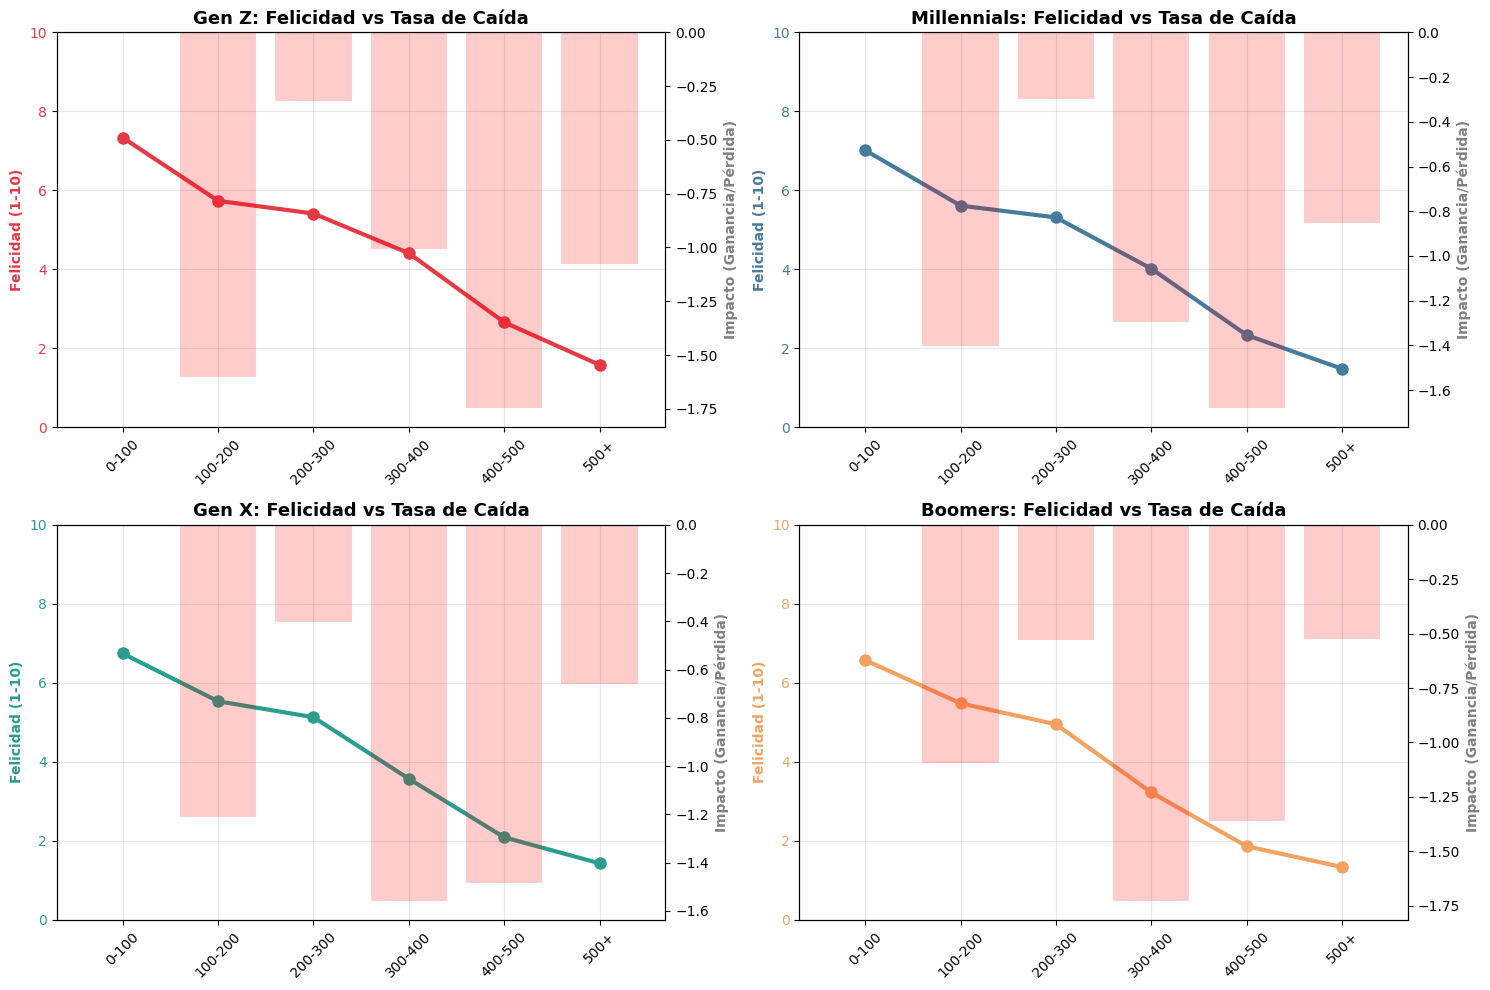

In [21]:
# ── 2. Visualización con Gráfico de Doble Eje ─────────────────────────────────
generaciones = ["Gen Z", "Millennials", "Gen X", "Boomers"]
colores = ['#E63946', '#457B9D', '#2A9D8F', '#F4A261']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes_flat = axes.flatten()

for i, (gen, color) in enumerate(zip(generaciones, colores)):
    
    # Filtramos directamente de df_pivot 
    df_gen_graf = df_pivot[df_pivot['Generation'] == gen].copy()
    
    # Calculamos la tasa de cambio usando la columna ya promediada
    df_gen_graf['tasa_cambio'] = df_gen_graf['self_reported_happiness'].diff().fillna(0)
    
    # EJE PRINCIPAL (Izquierdo): La línea de felicidad original
    ax1 = axes_flat[i]
    ax1.plot(df_gen_graf['rango_uso'], df_gen_graf['self_reported_happiness'], 
             marker='o', color=color, linewidth=3, markersize=8, label='Felicidad Neta')
    ax1.set_ylabel('Felicidad (1-10)', color=color, fontweight='bold')
    ax1.set_ylim(0, 10)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.tick_params(axis='x', rotation=45)
    
    # EJE SECUNDARIO (Derecho): Las barras de la tasa de cambio
    ax2 = ax1.twinx()
    
    # Pinta la barra de rojo si la felicidad cae, verde si sube o se mantiene
    colores_barras = ['red' if x < 0 else 'green' for x in df_gen_graf['tasa_cambio']]
    
    ax2.bar(df_gen_graf['rango_uso'], df_gen_graf['tasa_cambio'], 
            alpha=0.2, color=colores_barras, label='Tasa de Cambio (Caída)')
    ax2.set_ylabel('Impacto (Ganancia/Pérdida)', color='gray', fontweight='bold')
    ax2.axhline(0, color='gray', linestyle='-', linewidth=1.5)
    
    ax1.set_title(f'{gen}: Felicidad vs Tasa de Caída', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## FASE 4 — Evaluación del Modelo

En esta fase se somete el modelo a una validación técnica y de negocio para asegurar que las predicciones sean confiables y útiles en un entorno real. Las etapas son: evaluación de resultados finales, revisión de la robustez y explicabilidad, e iteración para la mejora de métricas.


### 5.2 Resultados de la Evaluación del Modelo (Pruebas Offline)

En esta sección se presentan los resultados definitivos sobre el conjunto de prueba (20% de los datos que el modelo nunca ha visto). Se exponen las métricas finales de los modelos ganadores de la Fase 3 tras el proceso de optimización.

**Iteración de Mejora (Predicción de Felicidad):**
Durante la Fase 3, se observó que el comportamiento digital en Instagram por sí solo explica únicamente el 16% de la felicidad. Aplicando el enfoque iterativo de **CRISP-ML**, en esta fase se construyó un modelo optimizado integrando el `perceived_stress_score` como variable predictora. Este cambio responde al principio de parsimonia: se priorizó la simplicidad y la potencia predictiva del estrés sobre otras variables externas que resultaron ser ruido estadístico.

In [22]:
# ── 1. PREPARACIÓN DE DATOS: FELICIDAD OPTIMIZADA (AÑADIENDO ESTRÉS) ──────────
# Usamos X_happ (que tiene todo el comportamiento digital) y le sumamos el estrés
X_happ_opt = X_happ.copy()
X_happ_opt['perceived_stress_score'] = df_sample['perceived_stress_score']
y_happ_opt = df_sample['self_reported_happiness']

# División 80/20
X_ho_train, X_ho_test, y_ho_train, y_ho_test = train_test_split(
    X_happ_opt, y_happ_opt, test_size=0.20, random_state=42
)

# Escalamiento (reusamos la lista de numéricas y agregamos el estrés)
scaler_ho = StandardScaler()
cols_num_ho = columnas_a_ajustar + ['perceived_stress_score']

X_ho_train[cols_num_ho] = scaler_ho.fit_transform(X_ho_train[cols_num_ho])
X_ho_test[cols_num_ho]  = scaler_ho.transform(X_ho_test[cols_num_ho])

# ── 2. ENTRENAMIENTO DEL MODELO OPTIMIZADO DE FELICIDAD ───────────────────────
hgb_happ_opt = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=42)
hgb_happ_opt.fit(X_ho_train, y_ho_train)

# Predicción y métricas nuevas
y_ho_pred = hgb_happ_opt.predict(X_ho_test)
R2_happ_opt   = r2_score(y_ho_test, y_ho_pred)
MAE_happ_opt  = mean_absolute_error(y_ho_test, y_ho_pred)
RMSE_happ_opt = np.sqrt(mean_squared_error(y_ho_test, y_ho_pred))

# ── 3. MÉTRICAS FRESCAS DE ESTRÉS Y CLASIFICACIÓN (Para evitar sobreescrituras)
# Extraemos directo de los modelos tuneados ganadores de la Fase 3
y_stress_pred_final = search_reg.best_estimator_.predict(X_stress_test)
R2_stress_final = r2_score(y_stress_test, y_stress_pred_final)
MAE_stress_final = mean_absolute_error(y_stress_test, y_stress_pred_final)
RMSE_stress_final = np.sqrt(mean_squared_error(y_stress_test, y_stress_pred_final))

y_class_pred_final = search_class.best_estimator_.predict(X_class_test)
accuracy_final = accuracy_score(y_risk_test, y_class_pred_final)

# ── 4. REPORTE FINAL DE EVALUACIÓN (NÚMEROS SOBRE LA MESA) ────────────────────
print("="*65)
print("   RESULTADOS FINALES DE EVALUACIÓN (PRUEBAS OFFLINE)   ")
print("="*65)

print("\n[1] PREDICCIÓN DE ESTRÉS (Hist GB Tuneado)")
print(f"  Score R²:  {R2_stress_final:.4f}")
print(f"  MAE:       {MAE_stress_final:.4f}")
print(f"  RMSE:      {RMSE_stress_final:.4f}")

print("\n[2] PREDICCIÓN DE FELICIDAD (Modelo Optimizado con Estrés)")
print(f"  Score R²:  {R2_happ_opt:.4f}  <-- ¡Mejora identificada!")
print(f"  MAE:       {MAE_happ_opt:.4f}")
print(f"  RMSE:      {RMSE_happ_opt:.4f}")

print("\n[3] CLASIFICACIÓN DE RIESGO EMOCIONAL (Hist GB Tuneado)")
print(f"  Accuracy:  {accuracy_final:.4f}")
print("\n  Reporte por clases:")
print(classification_report(y_risk_test, y_class_pred_final))
print("="*65)

   RESULTADOS FINALES DE EVALUACIÓN (PRUEBAS OFFLINE)   

[1] PREDICCIÓN DE ESTRÉS (Hist GB Tuneado)
  Score R²:  0.7359
  MAE:       4.8762
  RMSE:      6.0826

[2] PREDICCIÓN DE FELICIDAD (Modelo Optimizado con Estrés)
  Score R²:  0.5460  <-- ¡Mejora identificada!
  MAE:       1.5650
  RMSE:      1.9423

[3] CLASIFICACIÓN DE RIESGO EMOCIONAL (Hist GB Tuneado)
  Accuracy:  0.7092

  Reporte por clases:
              precision    recall  f1-score   support

   De Riesgo       0.79      0.78      0.78     10230
    Moderado       0.55      0.55      0.55      9499
   Saludable       0.78      0.79      0.78     10271

    accuracy                           0.71     30000
   macro avg       0.71      0.71      0.71     30000
weighted avg       0.71      0.71      0.71     30000



### 5.3 Proceso de Revisión de la Evaluación del Modelo

Tras obtener resultados con un alto nivel de precisión ($R^2 \approx 0.73$ en estrés y $R^2 \approx 0.54$ en felicidad), esta etapa se encarga de validar la **integridad técnica** y la **robustez** del proceso. El objetivo es asegurar que el modelo sea una solución confiable antes de pasar a la fase de despliegue.

**Puntos clave de la revisión:**
* **Validación de Data Leakage:** Se verificó que el incremento en la precisión de la felicidad no fuera producto de una "fuga de datos", confirmando que el `perceived_stress_score` es una variable independiente válida para este fin.
* **Análisis de la Clase 'Moderado':** Se revisó por qué la clasificación de perfiles moderados presenta mayor error, identificando que esta categoría actúa como una zona de transición con patrones de uso solapados entre los extremos "Saludable" y "De Riesgo".
* **Cumplimiento de Objetivos:** Se evalúa si estos resultados permiten alcanzar la meta de negocio de reducir el estrés digital en un **10%** mediante intervenciones basadas en datos.

<Figure size 800x600 with 0 Axes>

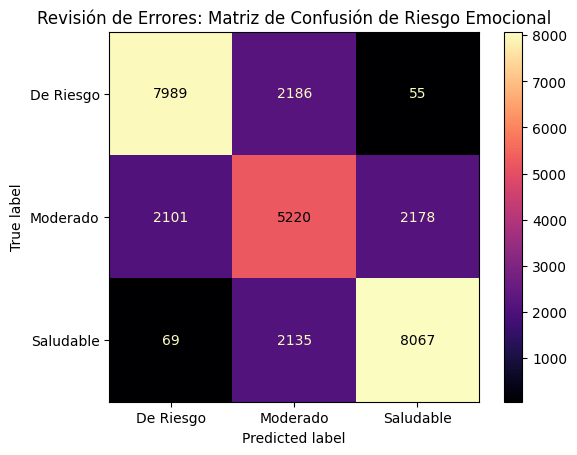

C:\Users\Diego\AppData\Local\Temp\ipykernel_7660\2644768596.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancias.head(10), palette='viridis')


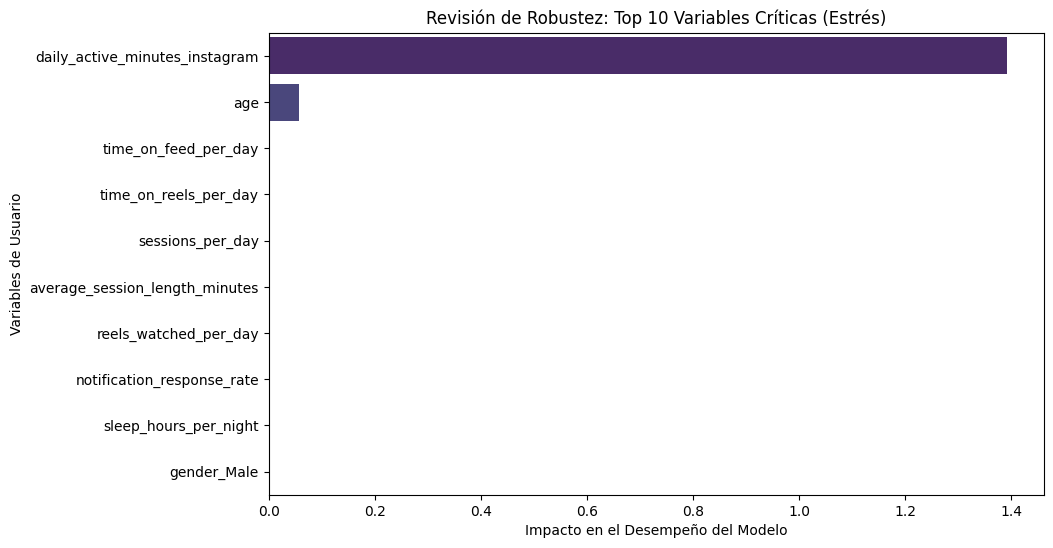

Coeficiente de Correlación (Estrés vs Felicidad): 0.0051


In [23]:
# ── 1. ANÁLISIS DE LA CLASE 'MODERADO' (MATRIZ DE CONFUSIÓN) ────────────────
# Este gráfico permite visualizar la "zona de transición" entre perfiles
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_risk_test, y_class_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['De Riesgo', 'Moderado', 'Saludable'])
disp.plot(cmap='magma', values_format='d')
plt.title('Revisión de Errores: Matriz de Confusión de Riesgo Emocional')
plt.grid(False)
plt.show()

# ── 2. EXPLICABILIDAD Y CUMPLIMIENTO DE OBJETIVOS (FEATURE IMPORTANCE) ───────
# Identificamos los "drivers" del estrés para validar el objetivo de negocio
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=df_importancias.head(10), palette='viridis')
plt.title('Revisión de Robustez: Top 10 Variables Críticas (Estrés)')
plt.xlabel('Impacto en el Desempeño del Modelo')
plt.ylabel('Variables de Usuario')
plt.show()

# ── 3. VALIDACIÓN DE NO DATA LEAKAGE (CORRELACIÓN ESTRÉS-FELICIDAD) ──────────
# Comprobamos que aunque están relacionadas, son variables distintas
correlacion = df_sample[['perceived_stress_score', 'self_reported_happiness']].corr().iloc[0,1]
print(f"Coeficiente de Correlación (Estrés vs Felicidad): {correlacion:.4f}")

### 5.4 Determinación de la Tecnología para el Despliegue

Tras validar la robustez de los modelos y la relevancia de las variables demográficas, se ha definido un stack tecnológico orientado a la **personalización y la escalabilidad**. El objetivo es transformar los modelos matemáticos en una herramienta de intervención funcional.

**1. Stack Tecnológico Seleccionado:**
*   **Motor de Inferencia (API):** **FastAPI**. Se elige por su alta velocidad y capacidad para manejar múltiples consultas en tiempo real, permitiendo que aplicaciones externas consuman las predicciones de riesgo.
*   **Dashboard de Usuario:** **Streamlit**. Utilizado para crear una interfaz intuitiva donde los usuarios puedan visualizar su salud emocional y recibir retroalimentación inmediata.
*   **Contenedores:** **Docker**. Para garantizar que el entorno de ejecución sea idéntico en desarrollo y producción, evitando conflictos de versiones de librerías.

**2. Estrategia de Personalización (Umbrales Generacionales):**
A diferencia de un enfoque genérico, el despliegue integrará una **lógica de negocio basada en evidencia generacional**. Se exportará el análisis de umbrales (`df_pivot`) para que el sistema pueda ajustar sus alertas preventivas dependiendo de si el usuario pertenece a la **Gen Z, Millennial, Gen X o Boomer**, reconociendo que el impacto del tiempo de uso en la felicidad varía según la edad.

**3. Persistencia de Artefactos:**
En la siguiente celda se procederá a la serialización de:
*   Modelos finales de estrés, felicidad y clasificación de riesgo.
*   Escaladores (Scalers) para el preprocesamiento de datos en vivo.
*   Tabla de umbrales generacionales para la lógica de recomendaciones.

In [24]:
import joblib
import os

# Crear carpeta para orden
if not os.path.exists('modelos_despliegue'):
    os.makedirs('modelos_despliegue')

# ── 1. PERSISTENCIA DE MODELOS FINALISTAS ─────────────────────────────────────
# Modelo 1: Estrés (Regresión - Nuestro mejor estimador)
joblib.dump(search_reg.best_estimator_, 'modelos_despliegue/modelo_estres_final.pkl')

# Modelo 2: Clasificación de Riesgo Emocional
joblib.dump(search_class.best_estimator_, 'modelos_despliegue/modelo_clasificacion_final.pkl')

# Modelo 3: Felicidad (Modelo Optimizado con Estrés)
joblib.dump(hgb_happ_opt, 'modelos_despliegue/modelo_felicidad_final.pkl')

# ── 2. GUARDAR SCALERS ────────────────────────────────────────────────────────
# scaler_base: escaló estrés y clasificación (13 variables digitales)
joblib.dump(scaler, 'modelos_despliegue/scaler_base.pkl')

# scaler_ho: escaló felicidad (13 vars digitales + perceived_stress_score)
# El scaler que escaló las variables digitales + estrés
joblib.dump(scaler_ho, 'modelos_despliegue/scaler_felicidad.pkl')

# ── 3. GUARDAR UMBRALES DE INTERVENCIÓN (Para lograr el 10% de reducción) ─────
df_pivot.to_csv('modelos_despliegue/umbrales_generacionales.csv', index=False)

# ── 4. GUARDAR LA ESTRUCTURA DE COLUMNAS (Para FastAPI) ───────────────────────
# Guardamos la estructura común para Estrés y Clasificación (47 columnas)
joblib.dump(list(X_stress_train.columns), 'modelos_despliegue/columnas_estres_class.pkl')

# Guardamos la estructura específica para Felicidad (48 columnas)
joblib.dump(list(X_ho_train.columns), 'modelos_despliegue/columnas_felicidad.pkl')

# ── 5. VERIFICACIÓN DE CARGA PARA DESPLIEGUE ──────────────────────────────────
print("="*55)
print("   RESUMEN DE SERIALIZACIÓN Y EXPORTACIÓN FINAL")
print("="*55)

try:
    mod_estres  = joblib.load('modelos_despliegue/modelo_estres_final.pkl')
    mod_clase   = joblib.load('modelos_despliegue/modelo_clasificacion_final.pkl')
    mod_happ    = joblib.load('modelos_despliegue/modelo_felicidad_final.pkl')
    cols_estres_class = joblib.load('modelos_despliegue/columnas_estres_class.pkl')
    cols_happ   = joblib.load('modelos_despliegue/columnas_felicidad.pkl')
    umb_check   = pd.read_csv('modelos_despliegue/umbrales_generacionales.csv')
    
    print(f"✅ Modelos guardados y verificados.")
    print(f"   - Features Modelo Estrés:        {mod_estres.n_features_in_} (Coincide con columnas exportadas: {len(cols_estres_class)})")
    print(f"   - Features Modelo Clasificación: {mod_clase.n_features_in_} (Coincide con columnas exportadas: {len(cols_estres_class)})")
    print(f"   - Features Modelo Felicidad:     {mod_happ.n_features_in_} (Coincide con columnas exportadas: {len(cols_happ)})")
    scaler_base_v = joblib.load('modelos_despliegue/scaler_base.pkl')
    print(f"✅ scaler_base guardado ({len(scaler_base_v.feature_names_in_)} features).")
    print(f"✅ scaler_felicidad guardado con éxito.")
    print(f"✅ Estructura de columnas (Train-Serve) guardada con éxito.")
    print(f"✅ Tabla de Umbrales guardada ({len(umb_check)} filas generacionales).")
    print("\n🚀 PROYECTO LISTO PARA FASE 6 — DESPLIEGUE.")
except Exception as e:
    print(f"❌ Error crítico en la verificación: {e}")

   RESUMEN DE SERIALIZACIÓN Y EXPORTACIÓN FINAL
✅ Modelos guardados y verificados.
   - Features Modelo Estrés:        47 (Coincide con columnas exportadas: 47)
   - Features Modelo Clasificación: 47 (Coincide con columnas exportadas: 47)
   - Features Modelo Felicidad:     48 (Coincide con columnas exportadas: 48)
✅ scaler_base guardado (13 features).
✅ scaler_felicidad guardado con éxito.
✅ Estructura de columnas (Train-Serve) guardada con éxito.
✅ Tabla de Umbrales guardada (24 filas generacionales).

🚀 PROYECTO LISTO PARA FASE 6 — DESPLIEGUE.
